<a href="https://colab.research.google.com/github/saffarizadeh/INSY5378/blob/main/Fundamentals_of_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://kambizsaffari.com/Logo/College_of_Business.cmyk-hz-lg.png" width="500px"/>

# *INSY 5378 - Advanced AI*

# **Fundamentals of Machine Learning**

Instructor: Dr. Kambiz Saffari

---

Note: You MUST read the chapter. Going through this notebook does not replace the value of reading the chapter.

Link to the chapter: https://deeplearningwithpython.io/chapters/chapter05_fundamentals-of-ml/

> *Disclaimer: This notebook is a personal study guide created for educational purposes. It summarizes and references material from "Deep Learning with Python, Third Edition" by François Chollet and Matthew Watson (Manning Publications). All rights to the original content, including text, images, and code, belong to the respective authors and publisher. This notebook is not intended for commercial use or redistribution. Please support the authors by purchasing the book at Manning.*

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

## Fundamentals of Machine Learning

This chapter covers:

- Understanding the tension between **generalization** and **optimization** - the fundamental issue in machine learning
- Evaluation methods for machine learning models
- Best practices to improve model fitting
- Best practices to achieve better generalization

After the three practical examples in the previous chapter (movie reviews, topic classification, house-price regression), you should be familiar with how to approach classification and regression problems using neural networks. You've also witnessed the central problem of machine learning: **overfitting**. This chapter will formalize those intuitions into a solid conceptual framework.

---

**Key terminology (Fundamentals Glossary)**

| Term | Definition |
|------|------------|
| Optimization | Adjusting a model to get the best performance on the *training* data |
| Generalization | How well the trained model performs on data it has *never seen* before |
| Overfitting | When the model learns patterns specific to the training data that don't generalize |
| Underfitting | When the model hasn't yet captured all the relevant patterns in the data |
| Manifold | A lower-dimensional subspace of a parent space that is locally similar to Euclidean space |
| Regularization | Techniques that actively impede the model from fitting the training data too perfectly |
| Feature engineering | Hardcoded (non-learned) transformations applied to data before it enters the model |
| Hyperparameters | Model configuration choices (e.g., number of layers, units per layer) - as opposed to learned *parameters* (weights) |
| Information leak | When validation-set information leaks into the model through repeated hyperparameter tuning |

### Generalization: The goal of machine learning

In the previous chapter, we split data into training, validation, and test sets. We observed that after a few epochs, performance on unseen data started *diverging* from training performance. The models started to **overfit**.

The fundamental issue in machine learning is the tension between **optimization** and **generalization**:

- **Optimization** = adjusting the model to perform as well as possible on the *training* data
- **Generalization** = how well the model performs on data it has *never seen*

You don't control generalization directly - you can only fit the model to training data. If you do that *too well*, overfitting kicks in and generalization suffers.

#### Underfitting and overfitting

For all models in the previous chapter, validation performance initially improved and then inevitably peaked and declined. This pattern is **universal**:

<img src="https://deeplearningwithpython.io/images/ch05/typical_overfitting.8bd4c216.png" width="500px"/>

At the beginning of training, optimization and generalization are *correlated* - lower training loss also means lower validation loss. The model is **underfitting**: it hasn't yet captured all relevant patterns. But after a certain point, generalization stops improving and validation metrics begin to degrade - the model is **overfitting**, learning patterns specific to the training data that are misleading or irrelevant for new data.

Overfitting is particularly likely when:
- Your data is **noisy**
- It involves **uncertainty** or ambiguity
- It includes **rare features**

##### Noisy training data

Real-world datasets often contain invalid or mislabeled inputs. For example, some MNIST training samples are barely recognizable:

<img src="https://deeplearningwithpython.io/images/ch05/weird_mnist.84598aa0.png" width="350px"/>

Even worse are perfectly valid inputs that end up **mislabeled**:

<img src="https://deeplearningwithpython.io/images/ch05/mislabeled_mnist.e7a71e65.png" width="350px"/>

If a model goes out of its way to incorporate such outliers, its generalization performance will degrade:

<img src="https://deeplearningwithpython.io/images/ch05/outliers_and_overfitting.919c6421.png" width="500px"/>


##### Ambiguous features

Even perfectly clean data can be noisy when the problem involves **uncertainty and ambiguity**. For example, classifying a banana as "unripened," "ripe," or "rotten" has no objective boundaries; different people may label the same photo differently. Similarly, using atmospheric pressure to predict rain involves inherent randomness.

<img src="https://deeplearningwithpython.io/images/ch05/overfitting_with_uncertainty.7eace2a5.png" width="500px"/>

A model could overfit to probabilistic data by being too confident about ambiguous regions. A more robust fit would ignore individual data points and look at the bigger picture.

##### Rare features and spurious correlations

Models trained on datasets with rare feature values are highly susceptible to overfitting. If a rare word like "cherimoya" appears in only one training text (which happens to be negative), the model might always classify new texts mentioning cherimoyas as negative - a spurious correlation.

Even features that appear in 100 samples can cause this: a 54%/46% positive/negative split may be a complete statistical fluke, but the model will learn to exploit it.

Here's a striking demonstration. We take MNIST and concatenate 784 **white noise** dimensions to the existing 784 real dimensions. For comparison, we also create a version with 784 **all-zeros** dimensions. The noise channels add no real information (i.e., human accuracy wouldn't change) but the model is affected.

In [2]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

# Add 784 random noise channels
train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

# Add 784 all-zeros channels (no noise)
train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

Now we train the same model on both datasets:

In [3]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8618 - loss: 0.4578 - val_accuracy: 0.9184 - val_loss: 0.2819
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9301 - loss: 0.2350 - val_accuracy: 0.9218 - val_loss: 0.2575
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9527 - loss: 0.1633 - val_accuracy: 0.9489 - val_loss: 0.1674
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9674 - loss: 0.1134 - val_accuracy: 0.9525 - val_loss: 0.1522
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.0828 - val_accuracy: 0.9566 - val_loss: 0.1447
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9821 - loss: 0.0601 - val_accuracy: 0.9607 - val_loss: 0.1302
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9874 - loss: 0.0442 - val_accuracy: 0.9621 - val_loss: 0.1256
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9934 - loss: 0.0275 - val_accuracy: 0.

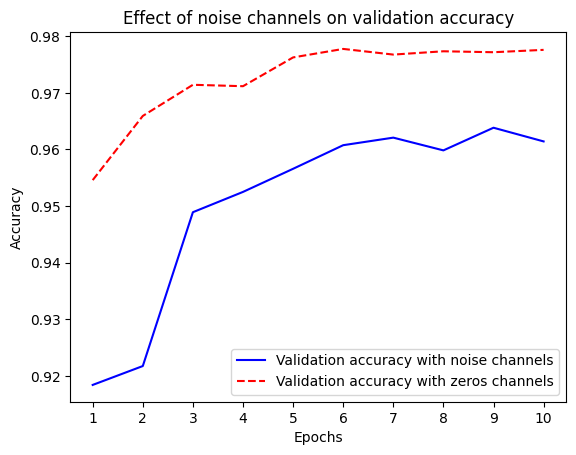

In [4]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Despite both datasets holding the same useful information, the model trained with noise channels ends up about one percentage point lower in validation accuracy; purely through the influence of **spurious correlations**. The more noise channels you add, the worse it gets.


This is why **feature selection** is common; restricting the IMDB data to the top 10,000 most common words was a crude form of this. The typical approach is to compute an informativeness score (such as mutual information between features and labels) and discard features below a threshold.

#### The nature of generalization in deep learning

A remarkable fact: deep learning models can be trained to **fit anything**, as long as they have enough representational power. To demonstrate, let's shuffle the MNIST labels randomly and try to train a model on that. There's no real relationship between inputs and shuffled labels, yet the training loss goes down just fine. Naturally, validation loss does not improve at all.

In [5]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]  # Copy
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1026 - loss: 2.3152 - val_accuracy: 0.1002 - val_loss: 2.3073
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1168 - loss: 2.2987 - val_accuracy: 0.1017 - val_loss: 2.3107
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1276 - loss: 2.2907 - val_accuracy: 0.1022 - val_loss: 2.3191
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1370 - loss: 2.2784 - val_accuracy: 0.0990 - val_loss: 2.3308
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1526 - loss: 2.2615 - val_accuracy: 0.0992 - val_loss: 2.3318
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1668 - loss: 2.2412 - val_accuracy: 0.0978 - val_loss: 2.3493
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1821 - loss: 2.2182 - val_accuracy: 0.0980 - val_loss: 2.3650
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1975 - loss: 2.1913 - val_accu

**A Side Note on Understanding RMSprop (Root Mean Square Propagation)**

In standard gradient descent, every parameter in the model is updated using the same learning rate. But this is often problematic; some parameters might need big updates to make progress, while others need tiny updates to avoid overshooting. Using one fixed learning rate for all of them is a compromise that doesn't serve anyone well.

RMSprop solves this by giving each parameter its own effective learning rate. It does this by tracking how large each parameter's gradients have been recently. If a parameter has been receiving large gradients, RMSprop automatically dials down its learning rate to prevent wild oscillations. If a parameter has been receiving small gradients, RMSprop increases its learning rate to help it make meaningful progress. Think of it as an automatic per-parameter volume knob; it turns down the loud ones and turns up the quiet ones so everything stays balanced.

This makes training faster and more stable, especially in situations where different parts of the model learn at very different speeds.

---

> **Note: Comparing common optimizers:**
>
> | Optimizer | What it does |
> |-----------|-------------|
> | **SGD** | Same fixed learning rate for every parameter. Simple but can be slow and sensitive to the learning rate choice. |
> | **SGD + Momentum** | Remembers which direction gradients have been pointing and builds up speed in that direction - like a ball rolling downhill that accumulates velocity. Faster than plain SGD. |
> | **RMSprop** | Adjusts the learning rate individually for each parameter based on how large its recent gradients have been. Good at handling parameters that learn at different speeds. |
> | **Adam** | Combines the ideas behind both Momentum and RMSprop. It builds up velocity in consistent directions *and* adjusts the learning rate per parameter. The most popular default in practice. |
>
> In this book, Chollet tends to use **RMSprop** as his go-to optimizer, while in the broader deep learning community **Adam** has become the most common default because it works well across a wide range of problems with minimal tuning. **SGD + Momentum** is still widely used in computer vision research because, despite being slower to converge, it can sometimes find solutions that generalize better. An important lesson from this chapter is that **the learning rate matters far more than the optimizer choice**; a bad learning rate will ruin training no matter which optimizer you use.

[Back to the problem at hand]

The model memorizes the random mapping, achieving high training accuracy, but validation accuracy stays near chance (~10%). This shows that the model is just memorizing, not learning meaningful patterns.

So if models can fit anything, **why do they generalize at all** on real data? The answer lies not in the model, but in the **structure of real-world data**.

##### The manifold hypothesis

An MNIST image is a 28×28 array of integers (0–255). The total possible inputs is 256^784, vastly more than atoms in the universe. Yet only a tiny fraction are valid handwritten digits.

This valid subspace is:
- **Continuous**: small modifications to a digit still produce a recognizable digit
- **Connected**: you can smoothly morph one digit into another

<img src="https://deeplearningwithpython.io/images/ch05/mnist_manifold.665acfb1.png" width="600px"/>

In technical terms, handwritten digits form a **manifold**, a lower-dimensional subspace that is locally similar to Euclidean space. Think of a smooth curve (1D manifold in 2D space) or a smooth surface (2D manifold in 3D space).

The **manifold hypothesis** states: *all natural data lies on a low-dimensional manifold within the high-dimensional space where it is encoded*. This is true for MNIST digits, human faces, tree shapes, speech, and even natural language. It's the reason deep learning works.

##### Interpolation as a source of generalization

If data points can be interpolated (smoothly connected along the manifold), you can make sense of **new points you've never seen** by relating them to nearby known points. This is the key mechanism behind deep learning generalization.

Importantly, interpolation on the **latent manifold** is different from **linear interpolation** in pixel space:

<img src="https://deeplearningwithpython.io/images/ch05/linear_interpolation_vs_manifold_interpolation.75960718.png" width="500px"/>

Deep learning achieves **local generalization** through interpolation. But humans are capable of **extreme generalization** through abstraction, reasoning, logic, and common sense, which are mechanisms that go beyond what current deep learning can do.

##### Why deep learning works

Remember the crumpled paper ball metaphor from previous sessions? A deep learning model is a tool for **uncrumpling** - disentangling latent manifolds.

<img src="https://deeplearningwithpython.io/images/ch02/geometric_interpretation_4.f8123b83.png" width="400px"/>

A deep learning model is a very high-dimensional curve that is:
- **Smooth and continuous** (because it must be differentiable for gradient descent)
- **Fitted incrementally** to data via gradient descent

During training, there's an intermediate point where the model roughly approximates the natural manifold of the data - before it starts memorizing:

<img src="https://deeplearningwithpython.io/images/ch05/the_cartoon_of_fitting.096e7b07.png" width="600px"/>

Key properties that make deep learning well-suited for manifold learning:
- **Smooth, continuous mapping** from inputs to outputs (required for differentiability)
- **Architecture priors** that mirror the structure of the data (e.g., convolutional networks for images)

##### Training data is paramount

The power to generalize comes more from the **structure of your data** than from properties of your model. For deep learning to work, your training data must be a **dense sampling** of the input manifold:

<img src="https://deeplearningwithpython.io/images/ch05/dense_sampling.c8a0767c.png" width="500px"/>

The best way to improve a deep learning model is to **train it on more or better data**. When more data isn't available, the next-best solution is **regularization** - constraining the model so it focuses on the most prominent, generalizable patterns.

### Evaluating machine-learning models

You can only control what you can observe. Since the goal is generalization, we need reliable ways to measure it.

#### Training, validation, and test sets

Evaluation always boils down to splitting data into **three** sets:

1. **Training set** - used to fit the model
2. **Validation set** - used to tune hyperparameters and monitor overfitting
3. **Test set** - used for final, one-time evaluation

**Why not just train/test?** Because tuning hyperparameters based on validation performance is itself a form of learning. Repeated tuning causes **information leaks** - the model indirectly overfits to the validation set. The test set must remain completely untouched until final evaluation.

Every time you adjust a hyperparameter based on validation performance, some information about the validation data leaks into your model. A few adjustments are fine, but many rounds of experimentation will cause the model to perform artificially well on validation data.

##### Simple hold-out validation

Set apart a fraction of data as the test set, then split the remaining data into training and validation:

<img src="https://deeplearningwithpython.io/images/ch05/holdout_validation.55d20cbc.png" width="500px"/>

**Pseudocode:**
```python
np.random.shuffle(data)  # Shuffle first!
validation_data = data[:num_validation_samples]
training_data = data[num_validation_samples:]

model = get_model()
model.fit(training_data, ...)
validation_score = model.evaluate(validation_data, ...)

# After tuning, retrain on all non-test data
model = get_model()
model.fit(np.concatenate([training_data, validation_data]), ...)
test_score = model.evaluate(test_data, ...)
```

**Weakness:** If little data is available, your validation and test sets may be too small to be statistically representative.

##### K-fold validation

Split data into **K** equal partitions. For each partition *i*, train on the remaining K-1 partitions and evaluate on partition *i*. The final score is the **average** of all K scores.

<img src="https://deeplearningwithpython.io/images/ch05/k_fold_validation.1fd60660.png" width="500px"/>

**Pseudocode:**
```python
k = 3
num_validation_samples = len(data) // k
np.random.shuffle(data)
validation_scores = []
for fold in range(k):
    validation_data = data[num_validation_samples * fold:
                           num_validation_samples * (fold + 1)]
    training_data = np.concatenate(
        data[:num_validation_samples * fold],
        data[num_validation_samples * (fold + 1):]
    )
    model = get_model()
    model.fit(training_data, ...)
    validation_scores.append(model.evaluate(validation_data, ...))

validation_score = np.average(validation_scores)
```

K-fold is especially helpful when model performance shows **significant variance** across different train/test splits.

##### Iterated K-fold validation with shuffling

For situations with very little data: apply K-fold validation **multiple times**, shuffling the data each time. The final score is the average across all runs. You end up training **P × K** models (P iterations × K folds), which can be expensive but gives the most precise evaluation.

#### Beating a common-sense baseline

Before starting work on any dataset, always establish a **trivial baseline** to beat:

| Problem | Baseline |
|---------|----------|
| MNIST digit classification | Random classifier: ~10% accuracy |
| IMDb sentiment (binary) | Random classifier: ~50% accuracy |
| Reuters (multiclass, imbalanced) | Always-predict-majority: ~18-19% accuracy |
| 90%/10% class imbalance | Always-predict-majority: 90% accuracy |

If you can't beat this baseline, something is fundamentally wrong with your approach - wrong model, wrong features, or perhaps the problem simply can't be solved with ML.

#### Things to keep in mind about model evaluation

When choosing an evaluation protocol, watch out for:

- **Data representativeness** - Both training and test sets should be representative. If digits are sorted by class and you take the first 80% for training, you'll train on classes 0-7 and test on 8-9. Always **randomly shuffle** before splitting.

- **The arrow of time** - For time-series problems (stock prices, weather), don't shuffle! Ensure all test data is *posterior* to training data to avoid **temporal leaks**.

- **Redundancy in data** - If data points appear twice, shuffling may put duplicates in both training and validation sets. Ensure the two sets are **disjoint**.

### Improving model fit

To achieve the perfect fit, **you must first overfit**. You can't know where the boundary lies without crossing it. Your initial goal is to achieve a model that:
1. Shows some generalization power (beats the baseline)
2. Is able to overfit

Three common problems at this stage:
- **Training doesn't get started** - loss doesn't go down
- **Model doesn't generalize** - can't beat the common-sense baseline
- **Can't overfit** - both training and validation loss go down, but no clear overfitting point

#### Tuning key gradient descent parameters

When training doesn't get started or stalls, it's **always** a configuration problem: optimizer, learning rate, batch size, or weight initialization. Remember: You can fit a model to random data, so if training isn't working, the issue is the gradient descent setup.

**Example: A learning rate that's too high.** Let's train the MNIST model with `learning_rate=1.0`:

In [6]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0997 - loss: 14.4819 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - v

The model gets stuck at 20–40% accuracy. Updates overshoot the optimal fit. Now let's fix it with `learning_rate=1e-2`:

In [7]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9102 - loss: 0.4065 - val_accuracy: 0.9564 - val_loss: 0.1560
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9648 - loss: 0.1276 - val_accuracy: 0.9611 - val_loss: 0.1449
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9730 - loss: 0.1012 - val_accuracy: 0.9685 - val_loss: 0.1418
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.0844 - val_accuracy: 0.9737 - val_loss: 0.1429
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9829 - loss: 0.0695 - val_accuracy: 0.9718 - val_loss: 0.1506
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9843 - loss: 0.0695 - val_accuracy: 0.9702 - val_loss: 0.1801
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9866 - loss: 0.0583 - val_accuracy: 0.9725 - val_loss: 0.1708
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9887 - loss: 0.0538 - val_accuracy: 0.

The model trains successfully now. When training stalls:
- **Lower or increase the learning rate** - too high causes overshooting, too low makes training appear stalled
- **Increase the batch size** - more samples per batch = more informative, less noisy gradients

#### Using better architecture priors

If the model trains but validation metrics never beat the baseline, something is **fundamentally wrong** with the approach:

- The input data may not contain sufficient information to predict targets (like our shuffled-labels experiment)
- The model architecture may be wrong for the problem (e.g., dense layers on time-series data when recurrent layers would work better)

Always use the **right architecture priors** for your data modality - convolutional networks for images, recurrent/transformer networks for sequences, etc.

#### Increasing model capacity

If validation metrics improve but you can't get the model to overfit, you need **more capacity**. Let's demonstrate with three models of increasing size.

**Model 1: Too small** - A simple logistic regression (no hidden layers):

In [8]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8298 - loss: 0.6833 - val_accuracy: 0.9044 - val_loss: 0.3626
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9029 - loss: 0.3536 - val_accuracy: 0.9147 - val_loss: 0.3093
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9113 - loss: 0.3180 - val_accuracy: 0.9192 - val_loss: 0.2941
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9155 - loss: 0.3019 - val_accuracy: 0.9219 - val_loss: 0.2831
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9178 - loss: 0.2922 - val_accuracy: 0.9231 - val_loss: 0.2791
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9201 - loss: 0.2854 - val_accuracy: 0.9244 - val_loss: 0.2736
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9217 - loss: 0.2805 - val_accuracy: 0.9262 - val_loss: 0.2726
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9230 - loss: 0.2767 - val_accuracy: 0.

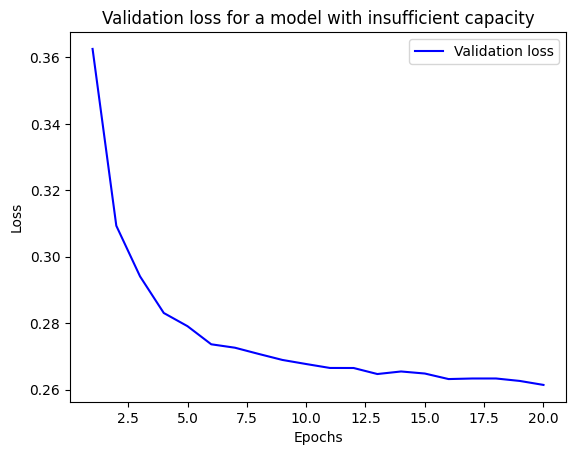

In [9]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Validation loss stalls instead of peaking and reversing. The model can't overfit because it doesn't have enough **representational power**.

**Model 2: Appropriate capacity** - two intermediate layers with 128 units:

In [10]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9029 - loss: 0.3390 - val_accuracy: 0.9514 - val_loss: 0.1746
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9567 - loss: 0.1449 - val_accuracy: 0.9654 - val_loss: 0.1214
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9708 - loss: 0.0977 - val_accuracy: 0.9657 - val_loss: 0.1169
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.0738 - val_accuracy: 0.9700 - val_loss: 0.0958
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.0581 - val_accuracy: 0.9723 - val_loss: 0.0885
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9854 - loss: 0.0473 - val_accuracy: 0.9734 - val_loss: 0.0874
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9875 - loss: 0.0388 - val_accuracy: 0.9757 - val_loss: 0.0847
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9900 - loss: 0.0311 - val_accuracy: 0.

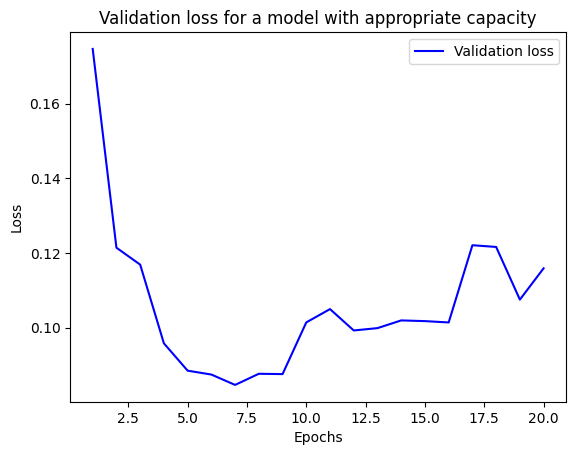

In [11]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Now the training curves look right: the model fits quickly and starts overfitting after about 8 epochs.

**Model 3: Too much capacity** - three layers with 2,048 units each:

In [12]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    # Smaller batch size to limit memory consumption for larger models
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9278 - loss: 0.2532 - val_accuracy: 0.9689 - val_loss: 0.1111
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9691 - loss: 0.1190 - val_accuracy: 0.9700 - val_loss: 0.1170
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9786 - loss: 0.0887 - val_accuracy: 0.9713 - val_loss: 0.1317
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9832 - loss: 0.0692 - val_accuracy: 0.9727 - val_loss: 0.1576
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9862 - loss: 0.0597 - val_accuracy: 0.9758 - val_loss: 0.1161
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9887 - loss: 0.0478 - val_accuracy: 0.9759 - val_loss: 0.1460
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9909 - loss: 0.0431 - val_accuracy: 0.9782 - val_loss: 0.1508
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9926 - loss: 0.0339 - 

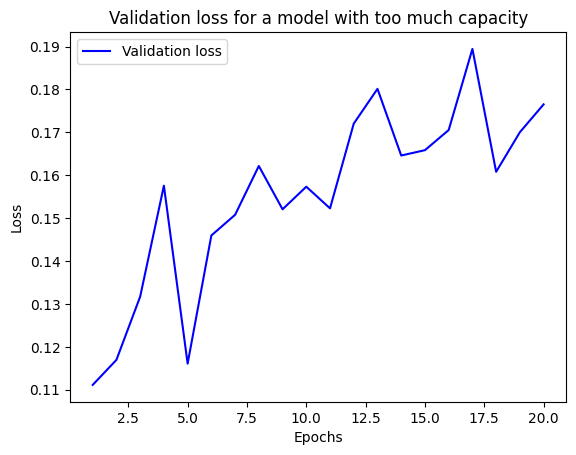

In [13]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

This model starts overfitting right away - the loss increases almost from the beginning.

**Takeaway:** The general workflow is to start with relatively few layers and parameters, then increase capacity until you see diminishing returns on validation loss.

### Improving generalization

Once your model shows generalization power and can overfit, it's time to **maximize generalization** by fighting overfitting.

#### Dataset curation

Generalization comes from the **latent structure** of your data. Spending more effort on data collection almost always yields a greater return than spending the same on model development:

- **Get enough data** - more data = better model. Problems that seem impossible may become solvable with a larger dataset.
- **Minimize labeling errors** - visualize inputs, proofread labels.
- **Clean your data** - handle missing values, remove anomalies.
- **Do feature selection** - if you aren't sure which features are useful, measure their informativeness and drop the rest.

#### Feature engineering

**Feature engineering** is using your domain knowledge to transform data into a form that makes the model's job easier. The classic example: reading a clock.

<img src="https://deeplearningwithpython.io/images/ch05/clock_diagram.3cbff177.png" width="500px"/>

- **Raw pixels** → Hard problem, needs a CNN and lots of compute
- **Hand tip (x, y) coordinates** → Simple ML algorithm works
- **Polar coordinates (angle θ)** → No ML needed, just rounding + lookup

Before deep learning, feature engineering was the *most important* part of ML. Modern neural networks can extract features automatically, but good features still:
- Let you solve problems more elegantly with **fewer resources**
- Let you solve problems with **far less data**

#### Using early stopping

Deep learning models are always vastly overparameterized - they have far more parameters than needed to fit the data manifold. But **you never fully fit them**. The goal is to stop at the sweet spot between underfitting and overfitting.

In practice, you can save the model at each epoch and reuse the one from the best epoch. Keras provides an `EarlyStopping` callback that automatically interrupts training when validation metrics stop improving, while remembering the best model state. (Covered in detail in Chapter 7.)

#### Regularizing your model

**Regularization techniques** actively impede the model from fitting the training data too perfectly, making it simpler and more generalizable. This should always be guided by accurate evaluation.

Common techniques:
1. Reducing the network's size
2. Adding weight regularization (L1/L2)
3. Adding dropout

##### Reducing the network's size

The simplest way to mitigate overfitting: **use a smaller model**. With limited memorization resources, the model is forced to learn *compressed representations* that have predictive power, exactly the kind of representations that generalize.

The workflow: start with few layers/parameters, increase until you see diminishing returns on validation loss.

Let's demonstrate with the IMDB movie review classification problem. First, the **original model** (baseline with 16 units per layer):

In [14]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7527 - loss: 0.5509 - val_accuracy: 0.8459 - val_loss: 0.4204
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8881 - loss: 0.3463 - val_accuracy: 0.8839 - val_loss: 0.3266
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9181 - loss: 0.2529 - val_accuracy: 0.8732 - val_loss: 0.3143
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9346 - loss: 0.2026 - val_accuracy: 0.8873 - val_loss: 0.2838
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9477 - loss: 0.1655 - val_accuracy: 0.8855 - val_loss: 0.2886
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9563 - loss: 0.1409 - val_accuracy: 0.8868 - val_loss: 0.2857
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9667 - loss: 0.1158 - val_accuracy: 0.8780 - val_loss: 0.3149
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9699 - loss: 0.1051 - val_accuracy: 0.8829 - v

Now a **smaller model** with only 4 units per layer:

In [15]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6377 - loss: 0.6290 - val_accuracy: 0.7737 - val_loss: 0.5813
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7735 - loss: 0.5481 - val_accuracy: 0.7254 - val_loss: 0.5408
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8324 - loss: 0.5026 - val_accuracy: 0.8102 - val_loss: 0.5054
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8676 - loss: 0.4693 - val_accuracy: 0.8433 - val_loss: 0.4845
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8918 - loss: 0.4429 - val_accuracy: 0.8380 - val_loss: 0.4729
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9089 - loss: 0.4207 - val_accuracy: 0.8532 - val_loss: 0.4591
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9218 - loss: 0.4012 - val_accuracy: 0.8418 - val_loss: 0.4612
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9345 - loss: 0.3843 - val_accuracy: 0.8376 - v

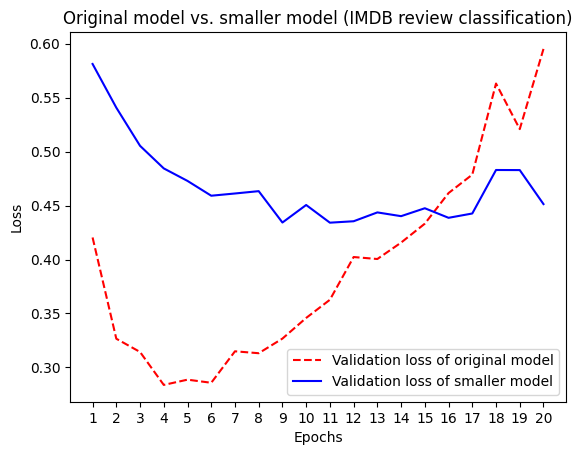

In [16]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

The smaller model starts overfitting **later** (after 6 epochs vs. 4) and degrades more slowly.

Now let's try a **much larger model** (512 units per layer):

In [17]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.4,
)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8225 - loss: 0.3954 - val_accuracy: 0.8729 - val_loss: 0.3060
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9247 - loss: 0.1904 - val_accuracy: 0.8850 - val_loss: 0.2951
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9674 - loss: 0.0923 - val_accuracy: 0.8826 - val_loss: 0.3488
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9894 - loss: 0.0338 - val_accuracy: 0.8846 - val_loss: 0.4519
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9931 - loss: 0.0228 - val_accuracy: 0.8823 - val_loss: 0.4862
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9982 - loss: 0.0074 - val_accuracy: 0.8831 - val_loss: 0.5711
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9974 - loss: 0.0088 - val_accuracy: 0.8842 - val_loss: 0.6039
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 3.5588e-04 - val_accurac

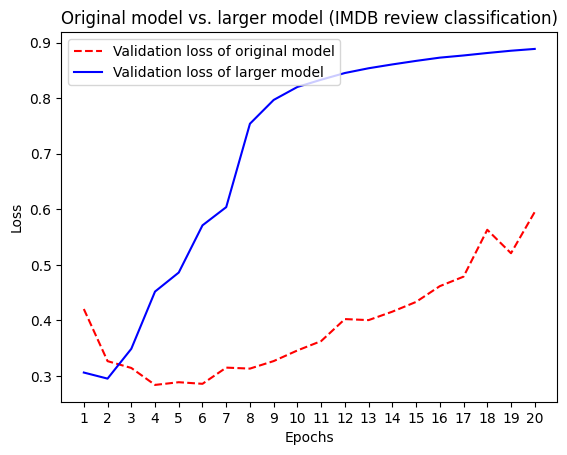

In [18]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

The bigger model starts overfitting **almost immediately** (after just 1 epoch) and overfits much more severely. It gets training loss near zero quickly, but the gap between training and validation loss is enormous.

##### Adding weight regularization

**Occam's razor**: given two explanations, the simpler one is more likely correct. This applies to neural networks: simpler models are less likely to overfit.

**Weight regularization** forces weights to take small values, making the model simpler. It adds a cost to the loss function for having large weights:

- **L1 regularization** - cost proportional to the *absolute value* of weights (L1 norm). Tends to push some weights to exactly zero (sparse models).
- **L2 regularization** (a.k.a. *weight decay*) - cost proportional to the *square* of weights (L2 norm). Pushes all weights toward small values.

Let's add L2 regularization to the IMDB model:

In [19]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7815 - loss: 0.6171 - val_accuracy: 0.8675 - val_loss: 0.4871
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8889 - loss: 0.4223 - val_accuracy: 0.8534 - val_loss: 0.4409
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9085 - loss: 0.3480 - val_accuracy: 0.8852 - val_loss: 0.3746
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9206 - loss: 0.3105 - val_accuracy: 0.8881 - val_loss: 0.3598
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9317 - loss: 0.2834 - val_accuracy: 0.8846 - val_loss: 0.3608
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9356 - loss: 0.2682 - val_accuracy: 0.8806 - val_loss: 0.3733
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9426 - loss: 0.2554 - val_accuracy: 0.8842 - val_loss: 0.3643
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9439 - loss: 0.2474 - val_accuracy: 0.8795 - v

`l2(0.002)` means every weight coefficient adds `0.002 * weight_value²` to the total loss. Note: this penalty is only added at **training time**, so training loss will be higher than test loss.

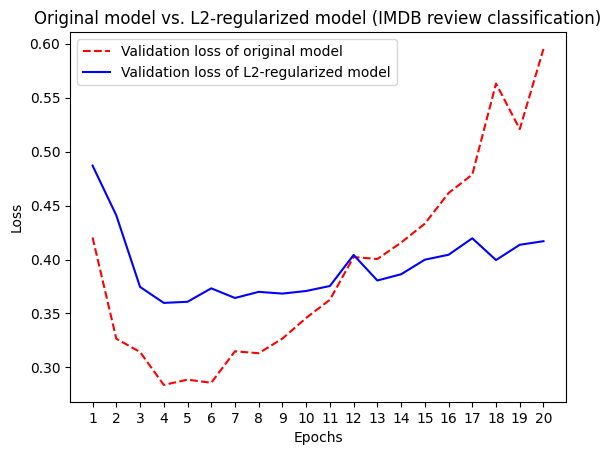

In [20]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

The L2-regularized model is **much more resistant to overfitting**, even though both models have the same number of parameters.

Keras also provides other regularizers:

In [21]:
from keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# Simultaneous L1 and L2 regularization
regularizers.l1_l2(l1=0.001, l2=0.001)

Weight regularization is more typically used for **smaller** deep learning models. Large models are so overparameterized that weight constraints don't have much effect. For those, **dropout** is preferred.

##### Adding dropout

**Dropout** (developed by Geoff Hinton et al.) is one of the most effective regularization techniques. It works by randomly **setting to zero** ("dropping out") a fraction of the layer's output features during training.

For example, a layer output of `[0.2, 0.5, 1.3, 0.8, 1.1]` might become `[0, 0.5, 1.3, 0, 1.1]` after dropout. The **dropout rate** (fraction zeroed out) is usually between 0.2 and 0.5.

At test time, no units are dropped. Instead, outputs are scaled down by the dropout rate to compensate (or equivalently, outputs are scaled *up* during training - this is the more common implementation).

<img src="https://deeplearningwithpython.io/images/ch05/dropout.8e0a70b8.png" width="500px"/>

**Why does this work?** Hinton's intuition came from bank fraud prevention: tellers get rotated frequently so that defrauding the bank would require cooperation between many changing employees. Similarly, randomly removing neurons on each training example prevents **"conspiracies"** - happenstance patterns that aren't meaningful but that the model would memorize without noise.

Let's add dropout to the IMDB model:

In [22]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6449 - loss: 0.6228 - val_accuracy: 0.8394 - val_loss: 0.4967
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7798 - loss: 0.4946 - val_accuracy: 0.8757 - val_loss: 0.3700
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8291 - loss: 0.4153 - val_accuracy: 0.8789 - val_loss: 0.3241
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8610 - loss: 0.3581 - val_accuracy: 0.8782 - val_loss: 0.3061
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8877 - loss: 0.3083 - val_accuracy: 0.8919 - val_loss: 0.2769
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9043 - loss: 0.2671 - val_accuracy: 0.8831 - val_loss: 0.2909
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9169 - loss: 0.2372 - val_accuracy: 0.8933 - val_loss: 0.2745
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9263 - loss: 0.2122 - val_accuracy: 0.8907 - v

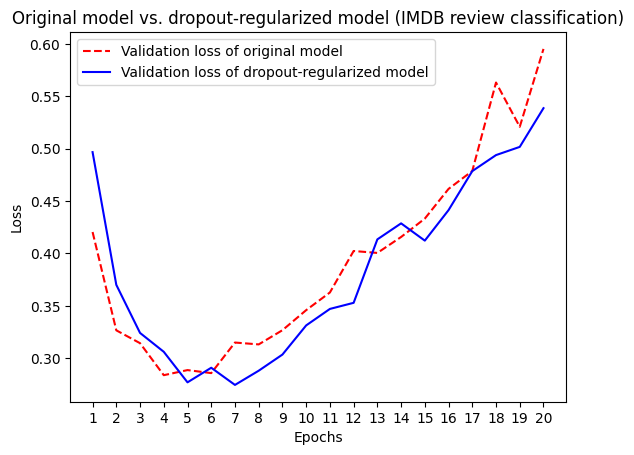

In [23]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

Dropout provides a clear improvement over the reference model, and appears to work even better than L2 regularization - the lowest validation loss reached has improved.


### Summary

The most common ways to **maximize generalization** and prevent overfitting:

1. **Get more training data** (or better data)
2. **Develop better features** (feature engineering)
3. **Reduce model capacity** (fewer layers/units)
4. **Add weight regularization** (L1/L2 - for smaller models)
5. **Add dropout** (for larger models)
6. **Use early stopping** (stop training at the right time)

---

**Key takeaways from this chapter:**

- The purpose of ML is to **generalize** - perform accurately on never-before-seen inputs.
- Deep networks generalize by learning to **interpolate** between training samples on a learned approximation of the **data manifold**.
- The fundamental challenge is the **tension between optimization and generalization**. Every best practice in this chapter deals with managing that tension.
- The **manifold hypothesis** says all natural data lies on low-dimensional manifolds within the high-dimensional encoding space. This is why deep learning works.
- Accurate **evaluation** is essential. Use hold-out validation, K-fold cross-validation, or iterated K-fold with shuffling. Always keep a separate **test set** for final evaluation.
- When starting a problem: first achieve a model that **can overfit** (tune learning rate, batch size, increase capacity, use appropriate architecture priors).
- Then **improve generalization** through regularization (reduce capacity, weight regularization, dropout) and early stopping.